#AI24: "Биржевая и внебиржевая торговля, оптимизация портфеля" (team 31)

# Чекпоинт №5 - Эксперименты с нелинейными моделями.

### Использование Кластеризации после AUTO-ML


In [2]:
#!pip install yfinance h2o scikit-learn networkx umap-learn

import yfinance as yf
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import h2o
from h2o.automl import H2OAutoML
from datetime import datetime

# Для статистик
from scipy.stats import skew, kurtosis

import warnings
warnings.filterwarnings("ignore")

Снова инициализация H2O:

In [3]:
h2o.init(max_mem_size="4G", nthreads=-1)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.26" 2025-01-21; OpenJDK Runtime Environment (build 11.0.26+4-post-Ubuntu-1ubuntu122.04); OpenJDK 64-Bit Server VM (build 11.0.26+4-post-Ubuntu-1ubuntu122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.11/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp2e7jbsry
  JVM stdout: /tmp/tmp2e7jbsry/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp2e7jbsry/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,4 months and 12 days
H2O_cluster_name:,H2O_from_python_unknownUser_x2able
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Список тикеров (из разных секторов)

In [5]:
tickers_full = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'BRK-B', 'JNJ', 'JPM', 'V',
    'PG', 'KO', 'PEP', 'XOM', 'CVX', 'WMT', 'HD', 'DIS', 'MA', 'NVDA',
    'NFLX', 'INTC', 'CSCO', 'ORCL', 'CRM', 'ABT', 'MRK', 'PFE', 'T', 'VZ',
    'BA', 'GE', 'MMM', 'HON', 'UNH', 'UPS', 'FDX', 'COST', 'SBUX', 'MCD',
    'ADBE', 'PYPL', 'INTU', 'QCOM', 'AMAT', 'TXN', 'IBM', 'LMT', 'NKE'
]

# (чтобы не перегружать AutoML)

num_assets = 20
tickers = random.sample(tickers_full, num_assets)

Повторение шагов из файла с AUTO-ML:

In [6]:
def compute_RSI(series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(window=period).mean()
    roll_down = down.rolling(window=period).mean()
    RS = roll_up / roll_down
    RSI = 100.0 - (100.0 / (1.0 + RS))
    return RSI

def compute_MACD(series, fast=12, slow=26, signal=9):
    exp1 = series.ewm(span=fast, adjust=False).mean()
    exp2 = series.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

In [7]:
def create_features_extended(series, n_lags=5):

    df = pd.DataFrame(series.copy())
    df.rename(columns={series.name: 'value'}, inplace=True)

    for lag in range(1, n_lags+1):
        df[f'lag_{lag}'] = df['value'].shift(lag)

    df['ma_5'] = df['value'].rolling(window=5).mean()
    df['ma_10'] = df['value'].rolling(window=10).mean()
    df['ma_20'] = df['value'].rolling(window=20).mean()

    df['vol_5'] = df['value'].rolling(window=5).std() # Волатильность

    df['RSI_14'] = compute_RSI(df['value'], period=14)

    macd, macd_signal = compute_MACD(df['value'])
    df['MACD'] = macd
    df['MACD_signal'] = macd_signal

    df['bollinger_mid'] = df['value'].rolling(window=20).mean()
    df['bollinger_std'] = df['value'].rolling(window=20).std()
    df['bollinger_upper'] = df['bollinger_mid'] + 2 * df['bollinger_std']
    df['bollinger_lower'] = df['bollinger_mid'] - 2 * df['bollinger_std']

    df.dropna(inplace=True)
    return df

Функции для AutoML-прогнозов:

In [15]:
def train_automl_model(df_train, feature_cols, target_col, max_runtime_secs=60, seed=42):

    train_h2o = h2o.H2OFrame(df_train)
    train_h2o[target_col] = train_h2o[target_col].asnumeric()

    aml = H2OAutoML(max_runtime_secs=max_runtime_secs, seed=seed, sort_metric="RMSE")
    aml.train(x=feature_cols, y=target_col, training_frame=train_h2o)
    return aml

1) Посл. строка из df (последний известный день)

2) Предсказываем на 1 шаг вперёд

3) Добавляем предсказание в конец ряда, пересчитываем фичи,
предсказываем следующий день и т.д.

In [17]:
def make_iterative_forecast(df, aml, feature_cols, horizon=30, target_col='target'):
    forecast_values = []
    df_current = df.copy()
    for _ in range(horizon):
        last_row = df_current.iloc[[-1]].copy()

        last_row_h2o = h2o.H2OFrame(last_row)
        pred = aml.leader.predict(last_row_h2o).as_data_frame()['predict'].values[0]
        forecast_values.append(pred)

        new_value = pred
        new_row = last_row.copy()
        new_row.index = [last_row.index[0] + pd.Timedelta(days=1)]

        for lag in range(1, 6):
            if lag == 1:
                new_row[f'lag_{lag}'] = last_row['value'].values[0]
            else:
                new_row[f'lag_{lag}'] = last_row[f'lag_{lag-1}'].values[0]

        df_current = pd.concat([df_current, new_row])
    return np.array(forecast_values)

In [13]:
def forecast_ticker_h2o(ticker, start_date='2021-01-01', end_date=None,
                        horizon=30, n_lags=5, max_runtime_secs=60,
                        forecast_task='return'):

    df_yf = yf.download(ticker, start=start_date, end=end_date)
    if df_yf.empty:
        return None

    if forecast_task == 'return':
        df_yf['value'] = df_yf['Close'].pct_change()
    else:
        df_yf['value'] = df_yf['Close']

    df_yf.dropna(inplace=True)
    if len(df_yf) < 50:
        return None

    hist_series = df_yf['value']
    hist_avg = hist_series.mean()
    hist_vol = hist_series.std()
    hist_skew_ = skew(hist_series)
    hist_kurt_ = kurtosis(hist_series)

    df_feat = create_features_extended(df_yf['value'], n_lags=n_lags)
    df_feat['target'] = df_feat['value'].shift(-1)
    df_feat.dropna(inplace=True)

    df_train = df_feat.iloc[:-1].copy()

    feature_cols = [c for c in df_train.columns if c not in ['target']]
    aml = train_automl_model(df_train, feature_cols, 'target',
                             max_runtime_secs=max_runtime_secs)

    forecast_base = df_feat.copy()
    forecast_vals = make_iterative_forecast(forecast_base, aml, feature_cols,
                                            horizon=horizon, target_col='target')

    fc_avg = np.mean(forecast_vals)
    fc_vol = np.std(forecast_vals)
    fc_skew_ = skew(forecast_vals)
    fc_kurt_ = kurtosis(forecast_vals)

    result = {
        'Ticker': ticker,
        'Hist_Avg': hist_avg,
        'Hist_Vol': hist_vol,
        'Hist_Skew': hist_skew_,
        'Hist_Kurt': hist_kurt_,
        'Fcst_Avg': fc_avg,
        'Fcst_Vol': fc_vol,
        'Fcst_Skew': fc_skew_,
        'Fcst_Kurt': fc_kurt_,
        'Returns_Series': df_yf['value']
    }
    return result

In [10]:
forecast_task = 'return'  # 'return' или 'price'
horizon = 30
max_runtime_secs = 40

In [11]:
results = []
returns_dict = {}

In [18]:
for t in tickers:
    res = forecast_ticker_h2o(
        t, start_date='2021-01-01', horizon=horizon,
        forecast_task=forecast_task,
        max_runtime_secs=max_runtime_secs
    )
    if res is not None:
        results.append(res)
        returns_dict[t] = res['Returns_Series']

df_features = pd.DataFrame(results)

[*********************100%***********************]  1 of 1 completed

Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |██████████████████████████████████████████████████

[*********************100%***********************]  1 of 1 completed

Parse progress: |

...

Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |██████████████████████████████████████████████████

[*********************100%***********************]  1 of 1 completed

Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Parse progress: |██████████████████████████████████████████████████

In [19]:
df_features.head()

,Ticker,Hist_Avg,Hist_Vol,Hist_Skew,Hist_Kurt,Fcst_Avg,Fcst_Vol,Fcst_Skew,Fcst_Kurt,Returns_Series
0,BA,0.000052,0.022993,-0.086720,1.862873,0.000041,1.355253e-20,1.000000,-2.000000,Date 2021-01-05 0.043952 2021-01-06 -0.00...
1,UPS,-0.000025,0.017236,-0.541839,13.597031,0.001831,3.096129e-04,4.124981,19.658911,Date 2021-01-05 -0.013920 2021-01-06 -0.00...
2,GE,0.001467,0.019342,-0.134038,2.500177,0.001664,6.098104e-05,-3.084476,8.986008,Date 2021-01-05 0.028653 2021-01-06 0.05...
3,TSLA,0.000750,0.038135,0.294078,2.588730,0.001818,2.900398e-04,-1.611308,8.478066,Date 2021-01-05 0.007317 2021-01-06 0.02...
4,PEP,0.000195,0.010655,-0.392049,2.769296,-0.000597,2.121454e-04,2.590612,5.860733,Date 2021-01-05 0.002981 2021-01-06 -0.01...


Корреляция активов (по ИСТОРИЧЕСКИМ доходностям/ценам)


In [20]:
df_returns = pd.DataFrame({t: returns_dict[t] for t in returns_dict})
df_returns.dropna(axis=0, how='any', inplace=True)
corr_matrix = df_returns.corr()

In [21]:
avg_corr = {}
for ticker in corr_matrix.columns:
    avg_corr[ticker] = corr_matrix[ticker].drop(ticker).mean()
df_features['Avg_Corr'] = df_features['Ticker'].map(avg_corr)

In [22]:
feature_cols = [
    'Fcst_Avg', 'Fcst_Vol', 'Hist_Avg', 'Hist_Vol',
    'Hist_Skew', 'Hist_Kurt', 'Fcst_Skew', 'Fcst_Kurt', 'Avg_Corr'
]
df_clust = df_features.dropna(subset=feature_cols).copy()  # чтобы не было NaN
X = df_clust[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_clust['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_clust['Agglo_Cluster'] = agg.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.0, min_samples=2)
df_clust['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

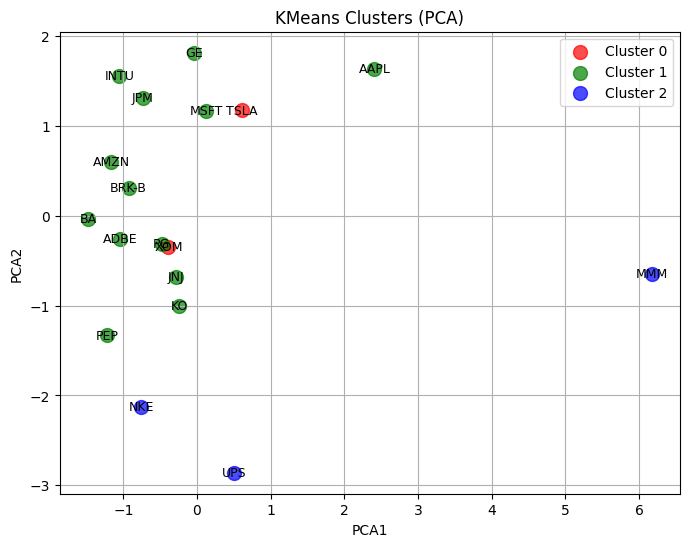

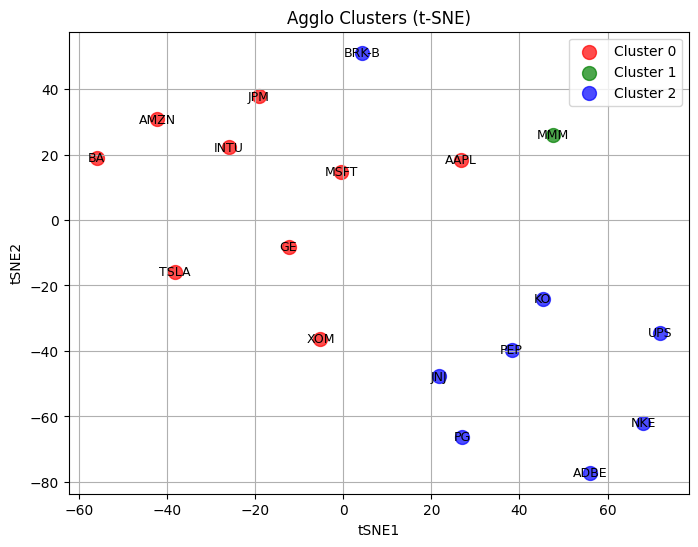

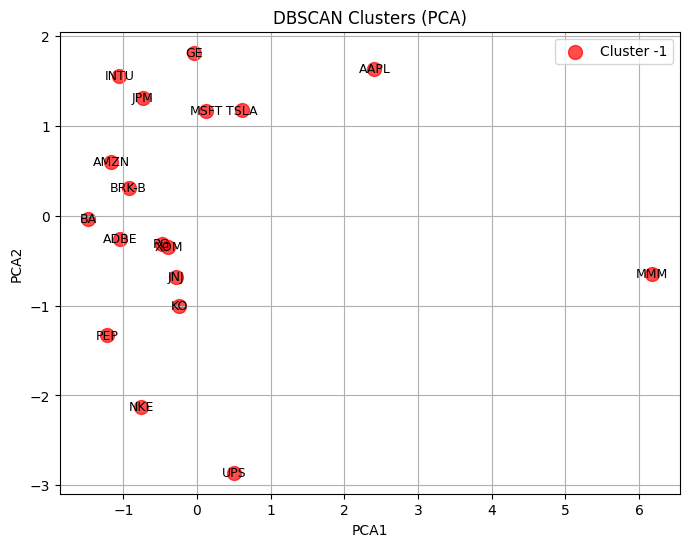

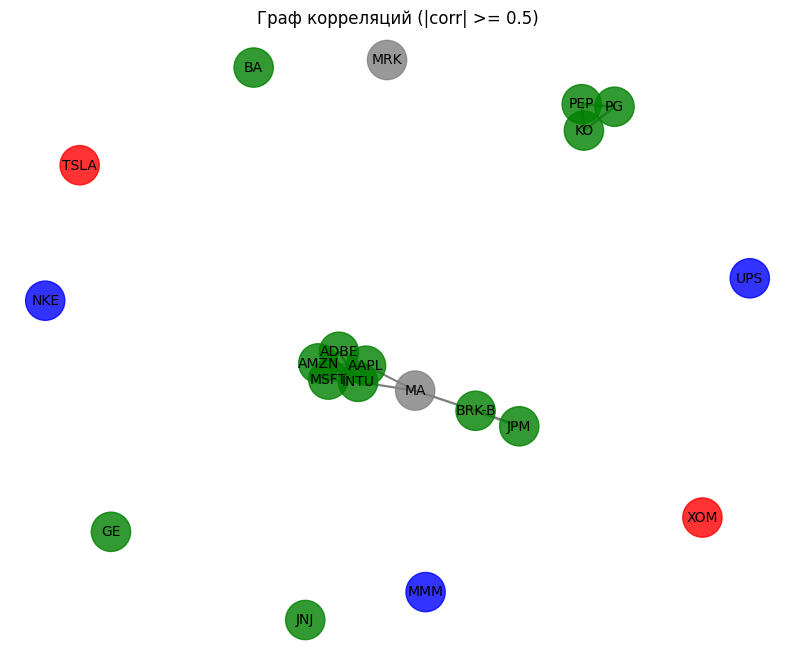

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clust['PCA1'] = X_pca[:, 0]
df_clust['PCA2'] = X_pca[:, 1]

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(X_scaled)
df_clust['tSNE1'] = X_tsne[:, 0]
df_clust['tSNE2'] = X_tsne[:, 1]

def plot_cluster_scatter(df, x_col, y_col, cluster_col, title):
    plt.figure(figsize=(8,6))
    clusters = df[cluster_col].unique()
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'yellow']
    for i, cl in enumerate(sorted(clusters)):
        subset = df[df[cluster_col] == cl]
        c = colors[i % len(colors)]
        plt.scatter(subset[x_col], subset[y_col], c=c, s=100, label=f"Cluster {cl}", alpha=0.7)
        for _, row in subset.iterrows():
            plt.text(row[x_col], row[y_col], row['Ticker'], fontsize=9, ha='center', va='center')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_cluster_scatter(df_clust, 'PCA1', 'PCA2', 'KMeans_Cluster', "KMeans Clusters (PCA)")
plot_cluster_scatter(df_clust, 'tSNE1', 'tSNE2', 'Agglo_Cluster', "Agglo Clusters (t-SNE)")
plot_cluster_scatter(df_clust, 'PCA1', 'PCA2', 'DBSCAN_Cluster', "DBSCAN Clusters (PCA)")

G = nx.Graph()
threshold = 0.5
for col in corr_matrix.columns:
    G.add_node(col)

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j:
            corr_val = corr_matrix.loc[i, j]
            if abs(corr_val) >= threshold:
                G.add_edge(i, j, weight=abs(corr_val))

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)
node_colors = []
for node in G.nodes():
    cluster_val = df_clust.loc[df_clust['Ticker'] == node, 'KMeans_Cluster']
    if not cluster_val.empty:
        cl = cluster_val.values[0]
    else:
        cl = -1
    color_map = ['red','green','blue','orange','purple','brown']
    node_colors.append(color_map[cl % len(color_map)] if cl>=0 else 'gray')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=10)
edges = G.edges(data=True)
edge_weights = [d['weight']*3 for (_,_,d) in edges]
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.5)
plt.title("Граф корреляций (|corr| >= 0.5)")
plt.axis('off')
plt.show()


In [25]:
for cl in sorted(df_clust['KMeans_Cluster'].unique()):
    sub = df_clust[df_clust['KMeans_Cluster'] == cl]
    print(f"\nКластер {cl}:")
    print(sub[['Ticker','Fcst_Avg','Fcst_Vol','Hist_Avg','Hist_Vol','Avg_Corr']])


Кластер 0:
  Ticker  Fcst_Avg  Fcst_Vol  Hist_Avg  Hist_Vol  Avg_Corr
3   TSLA  0.001818   0.00029   0.00075  0.038135  0.221669
6    XOM  0.001777   0.00010   0.00126  0.017429  0.173291

Кластер 1:
   Ticker  Fcst_Avg      Fcst_Vol  Hist_Avg  Hist_Vol  Avg_Corr
0      BA  0.000041  1.355253e-20  0.000052  0.022993  0.262138
2      GE  0.001664  6.098104e-05  0.001467  0.019342  0.279839
4     PEP -0.000597  2.121454e-04  0.000195  0.010655  0.278543
5    AAPL  0.007286  6.882758e-04  0.000638  0.016868  0.366841
7    MSFT  0.001542  2.907896e-04  0.000719  0.016450  0.352318
8   BRK-B  0.000776  1.755179e-05  0.000828  0.010722  0.401430
10   INTU  0.000668  3.252607e-19  0.000717  0.022012  0.347029
11   AMZN  0.000377  1.626303e-19  0.000446  0.022031  0.319841
15   ADBE -0.000274  8.958007e-05  0.000069  0.022912  0.304674
16     KO  0.002638  2.305485e-04  0.000421  0.009900  0.306315
17     PG  0.000257  1.212555e-04  0.000344  0.010761  0.259273
18    JNJ  0.000842  1.295481e-